In [28]:
from sklearn.datasets import make_regression
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [9]:
x, y =  make_regression(n_samples = 100 , n_features = 1 , n_informative = 1 , n_targets = 1 , noise = 12 , random_state = 14)

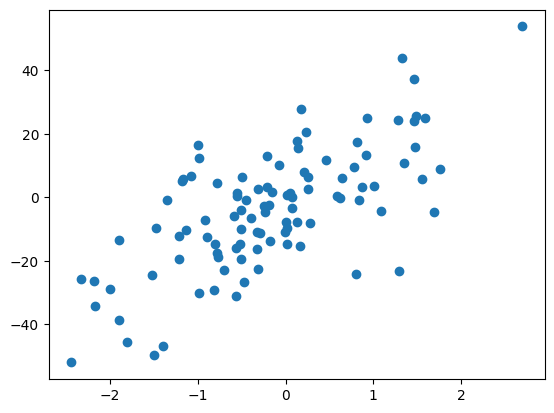

In [10]:
plt.scatter(x, y)

In [29]:
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size =  0.2 , random_state = 20)

In [11]:
from sklearn.linear_model import LinearRegression

In [30]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[13.17]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.011
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[10.]


In [31]:
print(lr.coef_)
print(lr.intercept_)

[13.16852135]
-2.0106749328242994


In [37]:
y_pred = lr.predict(x_test)
y_pred

array([ -3.97861196,   8.23359013, -14.94000957,  -8.20005308,
       -12.64541702,  -1.71950389,   1.06512542,   0.10271829,
        -6.15123431,  -9.74024445, -11.24173254,  -8.7240906 ,
        -2.96324055,   9.00093442,  12.27096921,   0.2803387 ,
        -1.01572715,  -5.13806283,  -8.7353491 ,   4.02720465])

In [38]:
from sklearn.metrics import r2_score
r2_score(y_pred , y_test)

-2.289589818576131

In [32]:
np.mean(cross_val_score(lr , x, y, scoring = 'r2' , cv = 10))

np.float64(0.36340521741480425)

In [33]:
class GDregressor :
    def __init__( self, epochs , LR):
        self.m = 15.88
        self.b = -100
        self.LR = LR
        self.epochs = epochs

    def fit( self , x, y):
        for i in range (self.epochs):
         loss_slope_b = -2 * np.sum(y - self.m* x.ravel() -self.b)
         loss_slope_m = - 2 * np.sum(( y - self.m* x.ravel()- self.b ) *x.ravel())
         step_size_b = self.LR * loss_slope_b
         step_size_m = self.LR *loss_slope_m
         self.b = self.b - step_size_b
         self.m = self.m - step_size_m
         print(self.m , self.b)

    def predict(self, x):
        return self.m *x +self.b

In [34]:
gd = GDregressor(100, 0.001)

In [40]:
gd.fit(x_train, y_train)

13.02042063403881 -1.7557474451799528
13.05888328200783 -1.8011572156136455
13.088005885866647 -1.8381012245327784
13.109976604343855 -1.8682254428905147
13.126481487793031 -1.892844206426272
13.138818257822372 -1.9130089452173018
13.147984504374401 -1.9295623660935275
13.15474602403434 -1.9431812137419116
13.159689746743933 -1.9544100575881773
13.163264705647181 -1.9636880212388212
13.165813733330566 -1.971369956778922
13.167597968106868 -1.9777432421247627
13.168815788008212 -1.9830411260997223
13.169617428071229 -1.9874533474768936
13.170116255193157 -1.9911345988533988
13.170397456328878 -1.994211284481339
13.170524726100354 -1.9967869257370834
13.170545408126513 -1.998946493033605
13.170494442097084 -2.0007598841954812
13.17039738923369 -2.002284723128396
13.17027274719439 -2.003568616294266
13.170133717710677 -2.0046509759154776
13.169989553210508 -2.0055644963086494
13.16984657997751 -2.0063363519846265
13.169708973159908 -2.006989172125556
13.16957934172463 -2.0075418349620557


In [41]:
y_pred1 = gd.predict(x_test)

In [42]:
r2_score(y_pred1 , y_test)

-2.28958981015697